###  **Seção 1: Otimização de Portfólio com Matriz de Covariância e Restrição de Cardinalidade**

A otimização de portfólio é problema de pesquisa operacional onde se decide **como alocar capital entre diferentes ativos financeiros**.

---

#### **Objetivo do Problema**

Queremos encontrar a melhor combinação de ativos financeiros que:

- **Maximize o retorno esperado**, considerando os pesos alocados em cada ativo;
- **Minimize o risco**, representado pela variância do portfólio com base na matriz de covariância;
- **Respeite restrições realistas**, como:
  - Selecionar no máximo **K ativos** (**restrição de cardinalidade**);
  - Impor limites de **investimento mínimo e máximo por ativo** (piso e teto);
  - Garantir que a **soma total dos pesos seja igual a 1** (100% do capital investido).

Essas restrições tornam o problema mais próximo da realidade, mas também mais complexo do ponto de vista computacional.


---

####  **Entendendo o problema e as Variáveis**

Vamos usar um exemplo com **4 ativos**:

1. **Apple (AAPL)**
2. **Google (GOOGL)**
3. **Amazon (AMZN)**
4. **Tesouro Direto (TD)** (renda fixa)

Para cada ativo nós temos :

$$
\mu_i = \text{retorno médio anual esperado do ativo } i \\
\sigma_i = \text{desvio padrão (volatilidade) do ativo } i \\
\rho_{i,j} = \text{correlação entre os ativos } i \text{ e } j \\
w_i = \text{peso (proporção do capital) investido no ativo } i
$$

Onde a soma dos pesos deve ser 100%:

$$
\sum_{i=1}^{n} w_i = 1
$$



| Ativo  | Retorno Esperado (μ) | Desvio Padrão (σ) |
|--------|-----------------------|--------------------|
| AAPL   | 0.12                  | 0.20               |
| GOOGL  | 0.10                  | 0.18               |
| AMZN   | 0.14                  | 0.25               |
| TD     | 0.05                  | 0.05               |

Correlação entre os ativos:

| Par de Ativos     | Correlação (ρ) |
|-------------------|----------------|
| AAPL & GOOGL      | 0.80           |
| AAPL & AMZN       | 0.75           |
| AAPL & TD         | 0.10           |
| GOOGL & AMZN      | 0.65           |
| GOOGL & TD        | 0.15           |
| AMZN & TD         | 0.20           |

---

####  **Passo a Passo: Construção da Matriz de Covariância**

A matriz de covariância é calculada com:

$$
\Sigma_{i,j} = \rho_{i,j} \cdot \sigma_i \cdot \sigma_j
$$

Substituindo os valores:

$$
\Sigma_{\text{AAPL, AAPL}} = 0.20^2 = 0.0400 \\
\Sigma_{\text{AAPL, GOOGL}} = 0.80 \cdot 0.20 \cdot 0.18 = 0.0288 \\
\Sigma_{\text{AAPL, AMZN}} = 0.75 \cdot 0.20 \cdot 0.25 = 0.0375 \\
\Sigma_{\text{AAPL, TD}} = 0.10 \cdot 0.20 \cdot 0.05 = 0.0010 \\
\Sigma_{\text{GOOGL, GOOGL}} = 0.18^2 = 0.0324 \\
\Sigma_{\text{GOOGL, AMZN}} = 0.65 \cdot 0.18 \cdot 0.25 = 0.02925 \\
\Sigma_{\text{GOOGL, TD}} = 0.15 \cdot 0.18 \cdot 0.05 = 0.00135 \\
\Sigma_{\text{AMZN, AMZN}} = 0.25^2 = 0.0625 \\
\Sigma_{\text{AMZN, TD}} = 0.20 \cdot 0.25 \cdot 0.05 = 0.0025 \\
\Sigma_{\text{TD, TD}} = 0.05^2 = 0.0025
$$

A matriz de covariância final será:

|         | AAPL   | GOOGL  | AMZN   | TD     |
|---------|--------|--------|--------|--------|
| **AAPL**  | 0.0400 | 0.0288 | 0.0375 | 0.0010 |
| **GOOGL** | 0.0288 | 0.0324 | 0.0293 | 0.0014 |
| **AMZN**  | 0.0375 | 0.0293 | 0.0625 | 0.0025 |
| **TD**    | 0.0010 | 0.0014 | 0.0025 | 0.0025 |

---

#### **Passo a Passo: Cálculo do Retorno Esperado**

Exemplo de alocação:

$$
w_{\text{AAPL}} = 0.3, \quad w_{\text{GOOGL}} = 0.2, \quad w_{\text{AMZN}} = 0.4, \quad w_{\text{TD}} = 0.1
$$

Com isso:

$$
E[R_p] = (0.3 \cdot 0.12) + (0.2 \cdot 0.10) + (0.4 \cdot 0.14) + (0.1 \cdot 0.05) = 0.117 \Rightarrow 11.7\%
$$

---

#### **Passo a Passo: Cálculo do Risco com a Matriz de Covariância**

$$
\sigma_p^2 = \mathbf{w}^T \cdot \Sigma \cdot \mathbf{w}
$$

Substituindo a matriz e o vetor de pesos, temos:

$$
\sigma_p^2 = 
(0.3, 0.2, 0.4, 0.1)
\begin{bmatrix}
0.0400 & 0.0288 & 0.0375 & 0.0010 \\
0.0288 & 0.0324 & 0.0293 & 0.0014 \\
0.0375 & 0.0293 & 0.0625 & 0.0025 \\
0.0010 & 0.0014 & 0.0025 & 0.0025
\end{bmatrix}
\begin{bmatrix}
0.3 \\
0.2 \\
0.4 \\
0.1
\end{bmatrix}
$$

Resultado:

$$
\sigma_p^2 \approx 0.03371 \quad \Rightarrow \quad \sigma_p \approx 18.36\%
$$

---

####  **Passo a Passo: Cálculo do Índice de Sharpe**

Assumindo taxa livre de risco \( R_f = 3\% = 0.03 \):

$$
SR = \frac{E[R_p] - R_f}{\sigma_p} = \frac{0.117 - 0.03}{0.1836} \approx 0.474
$$

---

#### **Restrição de Cardinalidade (K ativos)**

Na prática, é comum limitar o número de ativos no portfólio (ex: no máximo 10). Isso evita carteiras com muitos ativos irrelevantes.

Como o framework `CUSTOMHyS` trabalha apenas com variáveis contínuas, utilizaremos uma **heurística**:

- Geramos um vetor contínuo de pesos.
- Selecionamos os **K ativos com maiores pesos**.
- Zeros nos demais, e normalizamos os K pesos selecionados para somar 1.

---

#### **Fronteira Eficiente e Avaliação das Heurísticas**

A **Fronteira Eficiente Não Restrita (UEF)** representa todas as combinações de portfólio que **maximizam o retorno para um dado nível de risco** ou **minimizam o risco para um dado retorno**, **sem restrições de cardinalidade**.

No artigo de Chang et al. (2000), essa fronteira foi obtida por métodos exatos de otimização convexa e depois **salva em arquivos como `portef1`, `portef2` etc.** com pares 
$$
(\mu, \sigma^2)
$$
 para permitir **comparação com soluções heurísticas**.

Para avaliar a qualidade de uma solução com restrição de cardinalidade (obtida por heurística), os autores projetaram essa solução sobre a UEF. Isso foi feito por meio de interpolação linear entre os pontos da fronteira eficiente, permitindo encontrar a solução teórica mais próxima que apresenta o mesmo nível de risco ou retorno.
---

####  **O que é a Fronteira Eficiente?**

A Fronteira Eficiente é o **conjunto de portfólios ótimos**, ou seja, aqueles que:
- **Têm o menor risco possível** para um dado nível de retorno
- **Têm o maior retorno possível** para um dado nível de risco

Ela é representada graficamente por uma **curva convexa ascendente** no plano **risco × retorno**.

Imagine um gráfico com:
- Eixo X = risco (desvio padrão)
- Eixo Y = retorno esperado

A Fronteira Eficiente é a **borda superior da nuvem de pontos possíveis**, formando uma curva como essa:
#####  **Exemplo Prático**

Vamos supor que temos 1000 combinações aleatórias de portfólios feitos a partir dos ativos:
- AAPL (12%, 20%)
- GOOGL (10%, 18%)
- AMZN (14%, 25%)
- TD (5%, 5%)

Calculamos o retorno e risco de cada portfólio e traçamos todos esses pontos no plano:

$$
(\sigma, \mu)
$$

A **Fronteira Eficiente** será formada pelos **pontos mais ao norte e à esquerda** da nuvem.

Essa curva pode ser calculada resolvendo uma sequência de problemas de otimização para diferentes níveis de retorno (ou diferentes pesos):

$$
\lambda
$$

Quanto mais pontos usarmos, mais suave e precisa será a curva.

<img src=image.png alt="Fronteira Eficiente" width="45%"/>

---


####  **Métrica de Avaliação das Heurísticas**

A partir da curva UEF, os autores do artigo definiram as métricas:

- **Erro percentual na direção do risco**:

$$
\text{Erro}_{\text{risco}} = 100 \times \frac{\sigma^* - \sigma^{**}}{\sigma^{**}}
$$

- **Erro percentual na direção do retorno**:

$$
\text{Erro}_{\text{retorno}} = 100 \times \frac{\mu^* - \mu^{**}}{\mu^{**}}
$$

Onde:

$$
\begin{aligned}
(\mu^*, \sigma^*) &\text{ — solução encontrada pela heurística} \\
(\mu^{**}, \sigma^{**}) &\text{ — projeção correspondente na UEF}
\end{aligned}
$$

A **métrica final** adotada é o menor dos dois erros:

$$
\text{Erro final} = \min(\text{Erro}_{\text{risco}}, \text{Erro}_{\text{retorno}})
$$

Essa abordagem permite **comparar diretamente** o desempenho das heurísticas contra a fronteira ideal de mercado — uma métrica que é ao mesmo tempo quantitativa, interpretável e prática para aplicações científicas.

---

Essa abordagem nos permite **simular o comportamento do problema original com restrição de cardinalidade**, usando apenas variáveis contínuas. A próxima seção demonstrará isso na prática.



### 📊 **Seção 2: Resolvendo o problema com o customhys**

#### Instalando o package e baixando do github
 Utilize caso não esteja em um ambiente com o package instalado, como o google colab

In [1]:
# Clonar rep
# !git clone https://github.com/jcrvz/customhys.git .
# Instalar as dependências
# !pip install -r requirements.txt

# Instalar o CUSTOMHyS como pacote
# !pip install .
# %cd customhys
# %cd customhys

#### Função para ler instâncias OR-Library
Funções que leem instâncias que estão no formato OR-Library para o problema do portfólio single period

In [3]:
import numpy as np
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt




def read_or_library_instance(filepath):
    """
    Lê um arquivo de instância da OR-Library (ex: port1.txt) e retorna:
    - número de ativos
    - retornos esperados (μ_i)
    - desvios padrão (σ_i)
    - matriz de correlação (ρ_{i,j})
    - matriz de covariância (Σ)
    - dataframe da covariância para visualização
    """

    # Abre e lê todas as linhas do arquivo
    with open(filepath, 'r') as file:
        lines = file.readlines()

    # Número total de ativos financeiros disponíveis na instância
    n_assets = int(lines[0].strip())

    # Lê os retornos esperados e os desvios padrão (μ_i e σ_i)
    returns = []
    std_devs = []
    for i in range(1, n_assets + 1):
        mu, sigma = map(float, lines[i].strip().split())
        returns.append(mu)
        std_devs.append(sigma)

    # Inicializa a matriz de correlação com 1's na diagonal principal
    corr_matrix = np.eye(n_assets)

    # Lê os pares de ativos e suas respectivas correlações ρ_{i,j}
    for line in lines[n_assets + 1:]:
        i, j, rho = line.strip().split()
        i, j = int(i) - 1, int(j) - 1  # Corrige índice (de 1-based para 0-based)
        rho = float(rho)
        corr_matrix[i][j] = rho
        corr_matrix[j][i] = rho  # Simetria da matriz

    # Constrói a matriz de covariância Σ com:
    # Σ_{i,j} = ρ_{i,j} * σ_i * σ_j
    sigma_array = np.array(std_devs)
    cov_matrix = np.outer(sigma_array, sigma_array) * corr_matrix

    # Cria um DataFrame para visualização fácil da matriz de covariância
    df_cov = pd.DataFrame(
        cov_matrix,
        columns=[f"Asset {i+1}" for i in range(n_assets)],
        index=[f"Asset {i+1}" for i in range(n_assets)]
    )

    # Retorna um dicionário com todos os dados necessários
    return {
        "n_assets": n_assets,
        "returns": np.array(returns),         # Vetor de retornos esperados μ_i
        "std_devs": np.array(std_devs),       # Vetor de desvios padrão σ_i
        "corr_matrix": corr_matrix,           # Matriz de correlação ρ_{i,j}
        "cov_matrix": cov_matrix,             # Matriz de covariância Σ
        "df_cov": df_cov                      # DataFrame para visualização
    }


In [3]:
# Lê o arquivo port1 para testar
instance_data = read_or_library_instance("port1.txt")

print("\nMatriz de Covariância\n")
display(instance_data["df_cov"].round(5))  # Arredondando para facilitar a leitura


Matriz de Covariância



,Asset 1,Asset 2,Asset 3,Asset 4,Asset 5,Asset 6,Asset 7,Asset 8,Asset 9,Asset 10,...,Asset 22,Asset 23,Asset 24,Asset 25,Asset 26,Asset 27,Asset 28,Asset 29,Asset 30,Asset 31
Asset 1,0.00187,0.00098,0.00133,0.00137,0.00100,0.00163,0.00137,0.00124,0.00088,0.00147,...,0.00089,0.00133,0.00151,0.00162,0.00061,0.00140,0.00041,0.00084,0.00081,0.00082
Asset 2,0.00098,0.00162,0.00104,0.00103,0.00130,0.00113,0.00108,0.00101,0.00092,0.00107,...,0.00083,0.00107,0.00120,0.00134,0.00064,0.00115,0.00037,0.00080,0.00079,0.00072
Asset 3,0.00133,0.00104,0.00171,0.00141,0.00097,0.00155,0.00140,0.00128,0.00111,0.00144,...,0.00094,0.00140,0.00154,0.00169,0.00057,0.00146,0.00043,0.00092,0.00089,0.00087
Asset 4,0.00137,0.00103,0.00141,0.00202,0.00118,0.00171,0.00156,0.00144,0.00123,0.00153,...,0.00102,0.00170,0.00182,0.00177,0.00065,0.00152,0.00049,0.00096,0.00095,0.00092
Asset 5,0.00100,0.00130,0.00097,0.00118,0.00478,0.00127,0.00121,0.00116,0.00117,0.00106,...,0.00071,0.00130,0.00118,0.00138,0.00055,0.00130,0.00042,0.00064,0.00088,0.00063
Asset 6,0.00163,0.00113,0.00155,0.00171,0.00127,0.00288,0.00174,0.00156,0.00124,0.00186,...,0.00117,0.00175,0.00192,0.00194,0.00072,0.00174,0.00068,0.00111,0.00107,0.00102
Asset 7,0.00137,0.00108,0.00140,0.00156,0.00121,0.00174,0.00217,0.00146,0.00114,0.00173,...,0.00108,0.00157,0.00179,0.00179,0.00083,0.00179,0.00064,0.00104,0.00099,0.00103
Asset 8,0.00124,0.00101,0.00128,0.00144,0.00116,0.00156,0.00146,0.00207,0.00127,0.00138,...,0.00101,0.00167,0.00155,0.00162,0.00063,0.00148,0.00052,0.00101,0.00094,0.00095
Asset 9,0.00088,0.00092,0.00111,0.00123,0.00117,0.00124,0.00114,0.00127,0.00288,0.00106,...,0.00071,0.00127,0.00121,0.00129,0.00045,0.00120,0.00048,0.00082,0.00071,0.00082
Asset 10,0.00147,0.00107,0.00144,0.00153,0.00106,0.00186,0.00173,0.00138,0.00106,0.00220,...,0.00111,0.00152,0.00187,0.00179,0.00061,0.00165,0.00068,0.00107,0.00098,0.00099


#### Criando função de avaliação

A formulação é o **modelo de otimização de portfólio com restrição de cardinalidade** apresentado por **Chang et al. (2000)**:

---

### Função Objetivo :

$$
\min \left[ \lambda \sum_{i=1}^N \sum_{j=1}^N w_i w_j \sigma_{ij} \right] - (1 - \lambda) \left[ \sum_{i=1}^N w_i \mu_i \right]
$$

* **Objetivo:** minimizar uma combinação ponderada entre **risco** e **retorno**.
* $\lambda \in [0,1]$: parâmetro de ponderação entre risco e retorno.

  * Se $\lambda = 1$: foca 100% no risco.
  * Se $\lambda = 0$: foca 100% no retorno.
* $\sigma_{ij}$: covariância entre os ativos $i$ e $j$ → risco total do portfólio.
* $\mu_i$: retorno esperado do ativo $i$.
* $w_i$: peso do ativo $i$ na carteira.
* Essa função é equivalente a:

  $$
  \text{minimizar } \lambda \cdot \text{risco} - (1 - \lambda) \cdot \text{retorno}
  $$

---

###  Restrições

#### Soma dos pesos deve ser 1 (carteira completa):

$$
\sum_{i=1}^N w_i = 1
$$

> A soma das alocações no portfólio precisa ser 100% (normalização).

---

####  Restrição de cardinalidade:

$$
\sum_{i=1}^N z_i = K
$$

> Exige que **exatamente $K$** ativos sejam incluídos no portfólio.

* $z_i \in \{0, 1\}$: variável binária indicando se o ativo $i$ foi selecionado.

---

#### Limites mínimos e máximos de alocação por ativo:

$$
\varepsilon_i z_i \leq w_i \leq \delta_i z_i, \quad i = 1, \dots, N
$$

> Se $z_i = 1$, então $w_i$ deve estar entre $\varepsilon_i$ e $\delta_i$.
> Se $z_i = 0$, então $w_i = 0$ (ativo fora do portfólio).

---

#### Definição da variável binária:

$$
z_i \in \{0, 1\}, \quad i = 1, \dots, N
$$

> Garante que a variável $z_i$ seja binária (selecionado ou não).


In [4]:

# Lista global para registrar os resultados de cada avaliação da função
execution_logs = []


def portfolio_evaluation(
    weights, 
    instance_data, 
    k=None,                 
    lambda_=0.5, 
    risk_free_rate=0.03,
    epsilon=None,
    delta=None
):
    """
    Avalia um portfólio usando uma abordagem híbrida.
    - Se k for None, otimiza sem restrição de cardinalidade (usando todos os ativos).
    - Se epsilon/delta forem None, usa valores padrão (sem restrições de piso/teto).
    """
    n = instance_data["n_assets"]
    returns = instance_data["returns"]
    cov = instance_data["cov_matrix"]
    weights = np.array(weights)

    # --- INICIALIZAÇÃO DOS PARÂMETROS PADRÃO ---
    if epsilon is None:
        epsilon = np.zeros(n)
    if delta is None:
        delta = np.ones(n)
    
    # Se k não for especificado, o portfólio não tem restrição de cardinalidade (k = n).
    is_constrained = k is not None and k < n
    if not is_constrained:
        k = n

    # --- INÍCIO DO ALGORITMO DE REPARO ---
    
    # Seleciona os 'k' melhores ativos. Se k=n, seleciona todos.
    selected_indices = np.argsort(weights)[-k:]
    
    selected_epsilon = epsilon[selected_indices]
    selected_delta = delta[selected_indices]
    
    if np.sum(selected_epsilon) > 1.0:
        return 1e7, {"error": "Portfólio inviável: soma dos pisos > 1"} 

    final_k_weights = selected_epsilon.copy()
    free_assets_map = list(range(k)) 
    
    while True:
        free_capital = 1.0 - np.sum(final_k_weights)
        if free_capital < 1e-9: break
        
        s_i_free = weights[selected_indices[free_assets_map]]
        sum_s_i_free = np.sum(s_i_free)
        if sum_s_i_free > 1e-9:
            distribution = free_capital * (s_i_free / sum_s_i_free)
            final_k_weights[free_assets_map] += distribution
        
        violating_assets_map = [idx for idx in free_assets_map if final_k_weights[idx] > selected_delta[idx]]
        
        if not violating_assets_map:
            break
        else:
            for idx in violating_assets_map:
                final_k_weights[idx] = selected_delta[idx]
                free_assets_map.remove(idx)
    
    final_weights = np.zeros(n)
    final_weights[selected_indices] = final_k_weights

    # --- FIM DO ALGORITMO DE REPARO ---

    # --- AVALIAÇÃO E RETORNO ---
    expected_return = np.dot(final_weights, returns)
    variance = np.dot(final_weights, np.dot(cov, final_weights))
    
    portfolio_objective = lambda_ * variance - (1 - lambda_) * expected_return
    final_objective = portfolio_objective
    
    risk = np.sqrt(variance)
    sharpe = (expected_return - risk_free_rate) / risk if risk > 0 else -1e6
    execution_log = {
        "execution_number": len(execution_logs) + 1,
        "weights": final_weights.copy(),
        "selected_assets": np.where(final_weights > 0)[0].tolist(),
        "expected_return": expected_return,
        "risk": risk,
        "sharpe": sharpe,
        "final_objective": final_objective
    }
    execution_logs.append(execution_log)

    return final_objective, execution_log

##### Testando no portifólio de 4 ativos

In [14]:

# Exemplo de teste rápido
from_port1 = {
    "n_assets": 4,
    "returns": np.array([0.12, 0.10, 0.14, 0.05]),
    "cov_matrix": np.array([
        [0.0400, 0.0288, 0.0375, 0.0010],
        [0.0288, 0.0324, 0.0293, 0.0014],
        [0.0375, 0.0293, 0.0625, 0.0025],
        [0.0010, 0.0014, 0.0025, 0.0025]
    ])
}

# Executa a função
resultado, log = portfolio_evaluation([0.45, 0.2, 0.4, 0.1], from_port1,  risk_free_rate=0.03)

# Visualiza
df_log = pd.DataFrame([log])
display(df_log[["execution_number","weights", "selected_assets", "expected_return", "risk", "sharpe"]].round(5))

,execution_number,weights,selected_assets,expected_return,risk,sharpe
0,3289651,"[0.3913043478260869, 0.17391304347826086, 0.34...","[0, 1, 2, 3]",0.11739,0.18061,0.48387


#### Função para criar problema no formato que a hyperheuristica aceita, utilizando os probelmas já definidos acima

In [6]:
def configure_problem(instance_data, lambda_= 0.5,risk_free_rate=0.03, epsilon=None, delta=None, k=None):
    """
    Configura o problema no formato aceito pelo CUSTOMHyS.
    
    Parâmetros:
    - instance_data: dicionário retornado por read_or_library_instance()
    - k: restrição de cardinalidade (número máximo de ativos)
    - risk_free_rate: taxa livre de risco

    Retorna:
    - dicionário com as chaves esperadas por CUSTOMHyS
    """
    n = instance_data["n_assets"]
    lower_bounds = [0.00] * n
    upper_bounds = [1.00] * n
    return {
        "function": lambda weights: portfolio_evaluation(weights, instance_data, lambda_=lambda_, risk_free_rate=risk_free_rate, k = k, epsilon=epsilon, delta=delta)[0],
        "is_constrained": True,
        "boundaries": (lower_bounds, upper_bounds),
    }

In [7]:
# Carrega os dados da instância da OR-Library
instance_data = read_or_library_instance("port1.txt")

# Prepara o problema para o CUSTOMHyS com restrição de 10 ativos
problem_config = configure_problem(instance_data, lambda_=0.5, k=None)

# Verifica estrutura
import json
print(json.dumps(problem_config, indent=2, default=str))

{
  "function": "<function configure_problem.<locals>.<lambda> at 0x000001183B1F3E20>",
  "is_constrained": true,
  "boundaries": [
    [
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0,
      0.0
    ],
    [
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0,
      1.0
    ]
  ]
}


In [10]:
hh_config = {
    "cardinality": 10,  # Máximo de operadores na sequência
    "cardinality_min": 1,  # Mínimo de operadores na sequência
    "num_iterations":100,  # Número de iterações
    "num_agents": 30,  # Tamanho da população
    "as_mh": True,  # Usa a sequência de HH como uma metaheurística completa?
    "allow_weight_matrix": True,  # Permite matriz de pesos
    "num_replicas": 5,  # Número de réplicas por MH
    "num_steps": 30,  # Número de tentativas por passo da HH
    "stagnation_percentage": 0.40,  # Percentual de estagnação para controle
    "max_temperature": 100,  # Temperatura inicial (Simulated Annealing)
    "min_temperature": 1e-6,  # Temperatura mínima (Simulated Annealing)
    "cooling_rate": 0.01,  # Taxa de resfriamento (Simulated Annealing)
    "temperature_scheme": "fast",  # Esquema de temperatura
    "acceptance_scheme": "exponential",  # Critério de aceitação de soluções
    "trial_overflow": True,  # Política de overflow de tentativas
    "repeat_operators": True,  # Permite repetição de operadores na sequência
    "verbose": True,  # Exibir logs e progresso
    "learning_portion": 0.9,  # Percentual de aprendizado das sequências
    "solver": "static",  # Tipo de solver
    "initial_scheme": "sobol",  # Esquema inicial de seleção de operadores
}

#### Executando a hyperheuristica

In [11]:
from customhys.hyperheuristic import Hyperheuristic

#  Criar a instância da Hyper-Heurística
hh = Hyperheuristic(heuristic_space='default.txt', problem=problem_config, parameters=hh_config)

# Executar a otimização
print("\n [LOG] Iniciando execução da Hyper-Heurística\n")

execution_logs.clear()  # Limpa os logs antigos
cont = 0  # Reinicia o contador de execuções
result = hh.solve()  # Executa a otimização
df_logs = pd.DataFrame(execution_logs)


print("\n [LOG] Resultado da Hyper-Heurística:", result)
display(df_logs[["selected_assets", "expected_return", "risk", "sharpe"]].round(5))


 [LOG] Iniciando execução da Hyper-Heurística

Num_agents: 30, Num_iterations: 100, Initial_scheme: sobol
Verbose: False
Num_agents: 30, Num_iterations: 100, Initial_scheme: sobol
Verbose: False
Num_agents: 30, Num_iterations: 100, Initial_scheme: sobol
Verbose: False
Num_agents: 30, Num_iterations: 100, Initial_scheme: sobol
Verbose: False
Num_agents: 30, Num_iterations: 100, Initial_scheme: sobol
Verbose: False
 :: Step:    0, Temp: 1.00e+02, Perf: -1.73e-03 [Initial]
Num_agents: 30, Num_iterations: 100, Initial_scheme: sobol
Verbose: False
Num_agents: 30, Num_iterations: 100, Initial_scheme: sobol
Verbose: False
Num_agents: 30, Num_iterations: 100, Initial_scheme: sobol
Verbose: False
Num_agents: 30, Num_iterations: 100, Initial_scheme: sobol
Verbose: False
Num_agents: 30, Num_iterations: 100, Initial_scheme: sobol
Verbose: False
 :: Step:    1, Temp: 1.00e+02, Perf: -1.86e-03
, [Delta: -1.37e-04, ArgProb: 1.37e-06, Prob: 1.00] Num_agents: 30, Num_iterations: 100, Initial_scheme: s

,selected_assets,expected_return,risk,sharpe
0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.00331,0.03504,-0.76172
1,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.00401,0.03255,-0.79822
2,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.00369,0.03479,-0.75607
3,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.00318,0.03300,-0.81272
4,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...",0.00333,0.03275,-0.81446
...,...,...,...,...
3289645,"[0, 1, 2, 3, 4, 5, 7, 8, 13, 14, 15, 17, 18, 2...",0.00626,0.03488,-0.68070
3289646,"[0, 1, 2, 3, 4, 5, 7, 8, 13, 14, 15, 17, 18, 2...",0.00626,0.03488,-0.68070
3289647,"[0, 1, 2, 3, 4, 5, 7, 8, 13, 14, 15, 17, 18, 2...",0.00626,0.03488,-0.68070
3289648,"[0, 1, 2, 3, 4, 5, 7, 8, 13, 14, 15, 17, 18, 2...",0.00626,0.03488,-0.68070


In [12]:
# Exibe o DataFrame df_logs formatado
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.5f}'.format)

# Exibe as primeiras linhas do DataFrame para visualização rápida
print(df_logs.head(20).to_string())

    execution_number                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               weights                                                                                                     selected_assets  expected_return    risk   sharpe  final_objective
0                  1             [0.01965503114324869, 0.04517327964641596, 0.06451643384258865, 0.04217379254621204, 0.02791330356159

### 📌 **Seção 3: Comparando valores encontrados com a Fronteira eficiente**
Nessa seção iremos encontrar o valor ótimo por meio de força bruta, para compararmos com o valor dado pela hyperheuristica

<>:3: SyntaxWarning: invalid escape sequence '\s'
<>:3: SyntaxWarning: invalid escape sequence '\s'
C:\Users\João\AppData\Local\Temp\ipykernel_21308\613594381.py:3: SyntaxWarning: invalid escape sequence '\s'
  df_portef = pd.read_csv(file_path, sep="\s+", header=None, names=["mean_return", "variance"])


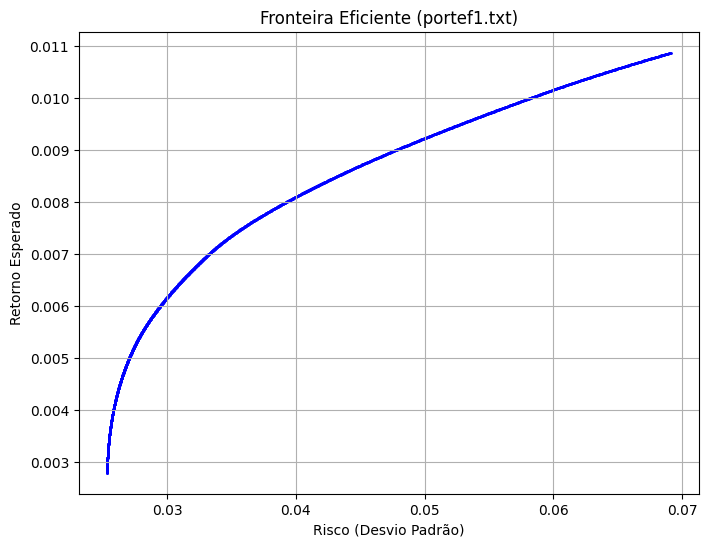

In [15]:
# Carrega os dados da fronteira eficiente
file_path = 'portef1.txt'
df_portef = pd.read_csv(file_path, sep="\s+", header=None, names=["mean_return", "variance"])
df_portef["std_dev"] = np.sqrt(df_portef["variance"])  # Calcula risco (desvio padrão)

# Plota com pontos individuais
plt.figure(figsize=(8, 6))
plt.scatter(df_portef["std_dev"], df_portef["mean_return"], s=1, color='blue')  # s=10 reduz o tamanho dos pontos
plt.title("Fronteira Eficiente (portef1.txt)")
plt.xlabel("Risco (Desvio Padrão)")
plt.ylabel("Retorno Esperado")
plt.grid(True)
plt.show()


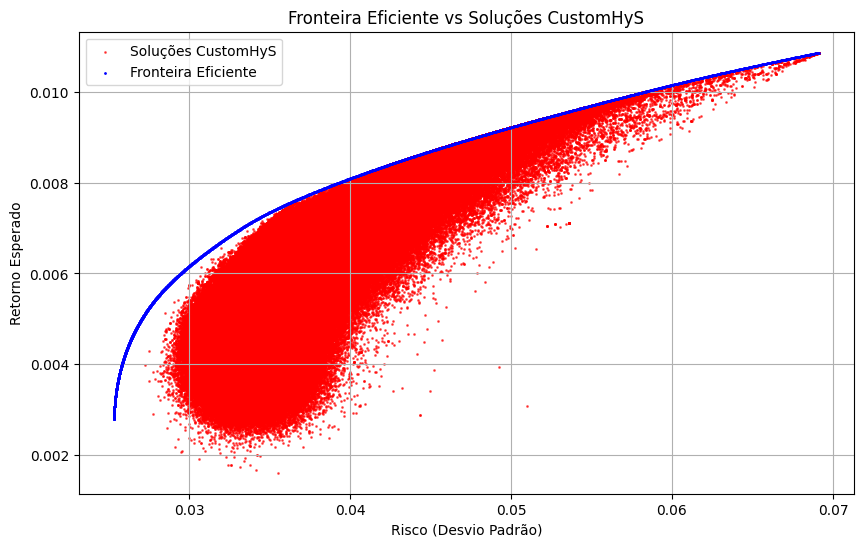

In [16]:
# 🔹 Gráfico: soluções vs fronteira eficiente
plt.figure(figsize=(10, 6))
plt.scatter(df_logs["risk"], df_logs["expected_return"], s=1, color='red', alpha=0.6, label="Soluções CustomHyS")
plt.scatter(df_portef["std_dev"], df_portef["mean_return"], s=1, color='blue', label="Fronteira Eficiente", zorder=5)  # zorder=5 para ficar na frente
plt.title("Fronteira Eficiente vs Soluções CustomHyS")
plt.xlabel("Risco (Desvio Padrão)")
plt.ylabel("Retorno Esperado")
plt.grid(True)
plt.legend(loc="upper left")
plt.show()

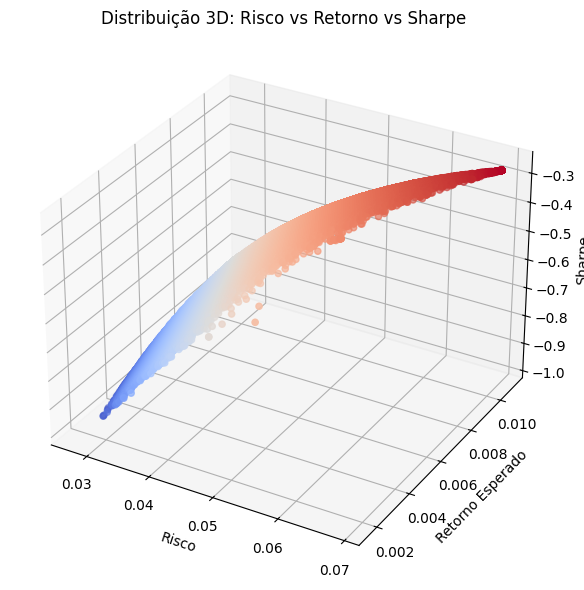

In [20]:
# Scatterplot 3D
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df_logs["risk"], df_logs["expected_return"], df_logs["sharpe"], c=df_logs["sharpe"], cmap='coolwarm')
ax.set_xlabel("Risco")
ax.set_ylabel("Retorno Esperado")
ax.set_zlabel("Sharpe")
ax.set_title("Distribuição 3D: Risco vs Retorno vs Sharpe")
plt.tight_layout()
plt.show()

### 📌 **Seção 4: Descontinuidade da Fronteira Eficiente sob Restrição de Cardinalidade**

Quando impomos uma **restrição de cardinalidade** $K < N$ (ou seja, o portfólio só pode conter no máximo $K$ ativos), a fronteira eficiente **deixa de ser uma curva contínua**.

**Por quê?** Sem restrição de cardinalidade, o espaço factível é convexo (um simplex), e a fronteira eficiente é uma curva suave. Ao impor $K$, o espaço factível se torna a **união de $\binom{N}{K}$ subespaços**, cada um correspondendo a um subconjunto de $K$ ativos. Cada subconjunto gera sua própria "mini-fronteira eficiente". A fronteira eficiente com cardinalidade é o **envelope inferior** dessas mini-fronteiras, que em geral **não é contínuo** — surgem **saltos e lacunas** nos pontos onde o subconjunto ótimo muda.

Abaixo demonstramos este fenômeno usando o portfólio de **4 ativos** já definido anteriormente, com $K = 2$.

In [8]:
from itertools import combinations
from scipy.optimize import minimize

# Portfólio de 4 ativos (já definido anteriormente)
N = 4
instance_4 = {
    "n_assets": N,
    "returns": np.array([0.12, 0.10, 0.14, 0.05]),
    "cov_matrix": np.array([
        [0.0400, 0.0288, 0.0375, 0.0010],
        [0.0288, 0.0324, 0.0293, 0.0014],
        [0.0375, 0.0293, 0.0625, 0.0025],
        [0.0010, 0.0014, 0.0025, 0.0025]
    ]),
}


def efficient_frontier_for_subset(indices, instance_data, n_points=300):
    """
    Calcula a fronteira eficiente (risco vs retorno) para um subconjunto de ativos,
    varrendo lambda de 0 a 1 e resolvendo o problema de Markowitz restrito ao subconjunto.
    """
    indices = list(indices)
    returns = instance_data["returns"][indices]
    cov = instance_data["cov_matrix"][np.ix_(indices, indices)]
    n = len(indices)

    risks, rets = [], []

    for lam in np.linspace(0, 1, n_points):
        def objective(w, _lam=lam):
            return _lam * (w @ cov @ w) - (1 - _lam) * (returns @ w)

        constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
        bounds = [(0, 1)] * n
        w0 = np.ones(n) / n

        res = minimize(objective, w0, method='SLSQP', bounds=bounds, constraints=constraints)
        if res.success:
            w = res.x
            ret = returns @ w
            risk = np.sqrt(w @ cov @ w)
            risks.append(risk)
            rets.append(ret)

    return np.array(risks), np.array(rets)


def compute_all_subset_frontiers(instance_data, k):
    """
    Para um dado K, enumera todos os C(N,K) subconjuntos de ativos
    e calcula a fronteira eficiente de cada um.
    """
    n = instance_data["n_assets"]
    all_subsets = list(combinations(range(n), k))
    frontiers = {}

    for subset in all_subsets:
        # Rótulos genéricos: Ativo 1, Ativo 2, ...
        label = " + ".join([f"Ativo {i+1}" for i in subset])
        risks, rets = efficient_frontier_for_subset(subset, instance_data)
        frontiers[label] = (risks, rets)

    return frontiers


print(f"N = {N} ativos")
print(f"Número de subconjuntos para K=2: C({N},2) = {len(list(combinations(range(N), 2)))}")
print(f"Número de subconjuntos para K=3: C({N},3) = {len(list(combinations(range(N), 3)))}")
print("Funções definidas com sucesso.")

N = 4 ativos
Número de subconjuntos para K=2: C(4,2) = 6
Número de subconjuntos para K=3: C(4,3) = 4
Funções definidas com sucesso.


#### Fronteiras individuais de cada subconjunto com $K = 2$

Cada par de ativos gera sua própria curva no espaço risco × retorno. O **envelope** (borda inferior-esquerda) dessas curvas é a fronteira eficiente com restrição de cardinalidade $K=2$. Note os **saltos e descontinuidades** entre as curvas.

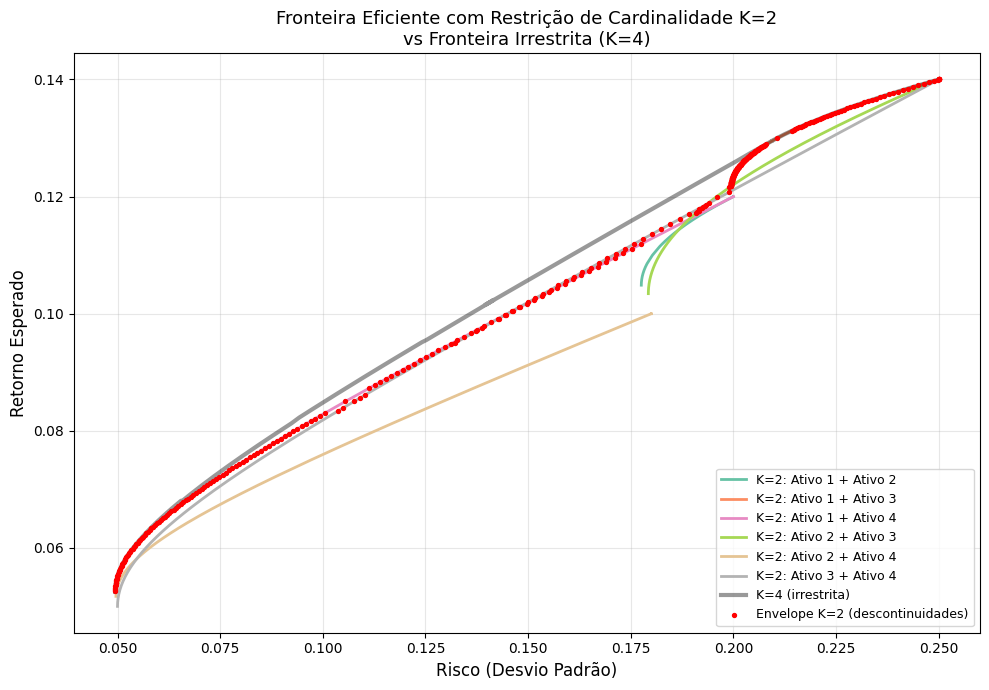

In [9]:
# --- Gráfico 1: Fronteiras de cada par de ativos (K=2) vs fronteira irrestrita (K=N) ---

frontiers_k2 = compute_all_subset_frontiers(instance_4, k=2)
frontiers_kn = compute_all_subset_frontiers(instance_4, k=instance_4["n_assets"])

fig, ax = plt.subplots(figsize=(10, 7))

# Plota cada par de ativos com cor distinta
colors = plt.cm.Set2(np.linspace(0, 1, len(frontiers_k2)))
for (label, (risks, rets)), color in zip(frontiers_k2.items(), colors):
    ax.plot(risks, rets, '-', linewidth=2, color=color, label=f'K=2: {label}')

# Plota a fronteira irrestrita (K=N) como referência
for label, (risks, rets) in frontiers_kn.items():
    ax.plot(risks, rets, 'k-', linewidth=3, alpha=0.4, label=f'K={instance_4["n_assets"]} (irrestrita)')

# Constrói o envelope (fronteira eficiente com cardinalidade K=2)
# Agrupa todos os pontos de K=2 e encontra a fronteira de Pareto
all_risks_k2 = np.concatenate([r for r, _ in frontiers_k2.values()])
all_rets_k2 = np.concatenate([r for _, r in frontiers_k2.values()])

# Ordena por retorno e filtra pontos dominados (Pareto front)
sorted_idx = np.argsort(all_rets_k2)
pareto_risks, pareto_rets = [], []
min_risk = np.inf
for i in sorted_idx[::-1]:  # Do maior retorno para o menor
    if all_risks_k2[i] < min_risk:
        pareto_risks.append(all_risks_k2[i])
        pareto_rets.append(all_rets_k2[i])
        min_risk = all_risks_k2[i]

pareto_risks = np.array(pareto_risks[::-1])
pareto_rets = np.array(pareto_rets[::-1])

# Plota o envelope como pontos para evidenciar descontinuidades
ax.scatter(pareto_risks, pareto_rets, s=8, color='red', zorder=10, label='Envelope K=2 (descontinuidades)')

ax.set_xlabel("Risco (Desvio Padrão)", fontsize=12)
ax.set_ylabel("Retorno Esperado", fontsize=12)
ax.set_title("Fronteira Eficiente com Restrição de Cardinalidade K=2\n"
             f"vs Fronteira Irrestrita (K={instance_4['n_assets']})", fontsize=13)
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Comparação: efeito progressivo da cardinalidade $K = 1, 2, 3, 4$

Conforme $K$ aumenta em direção a $N$, a fronteira eficiente se torna **mais suave e contínua**, convergindo para a fronteira de Markowitz clássica quando $K = N$.

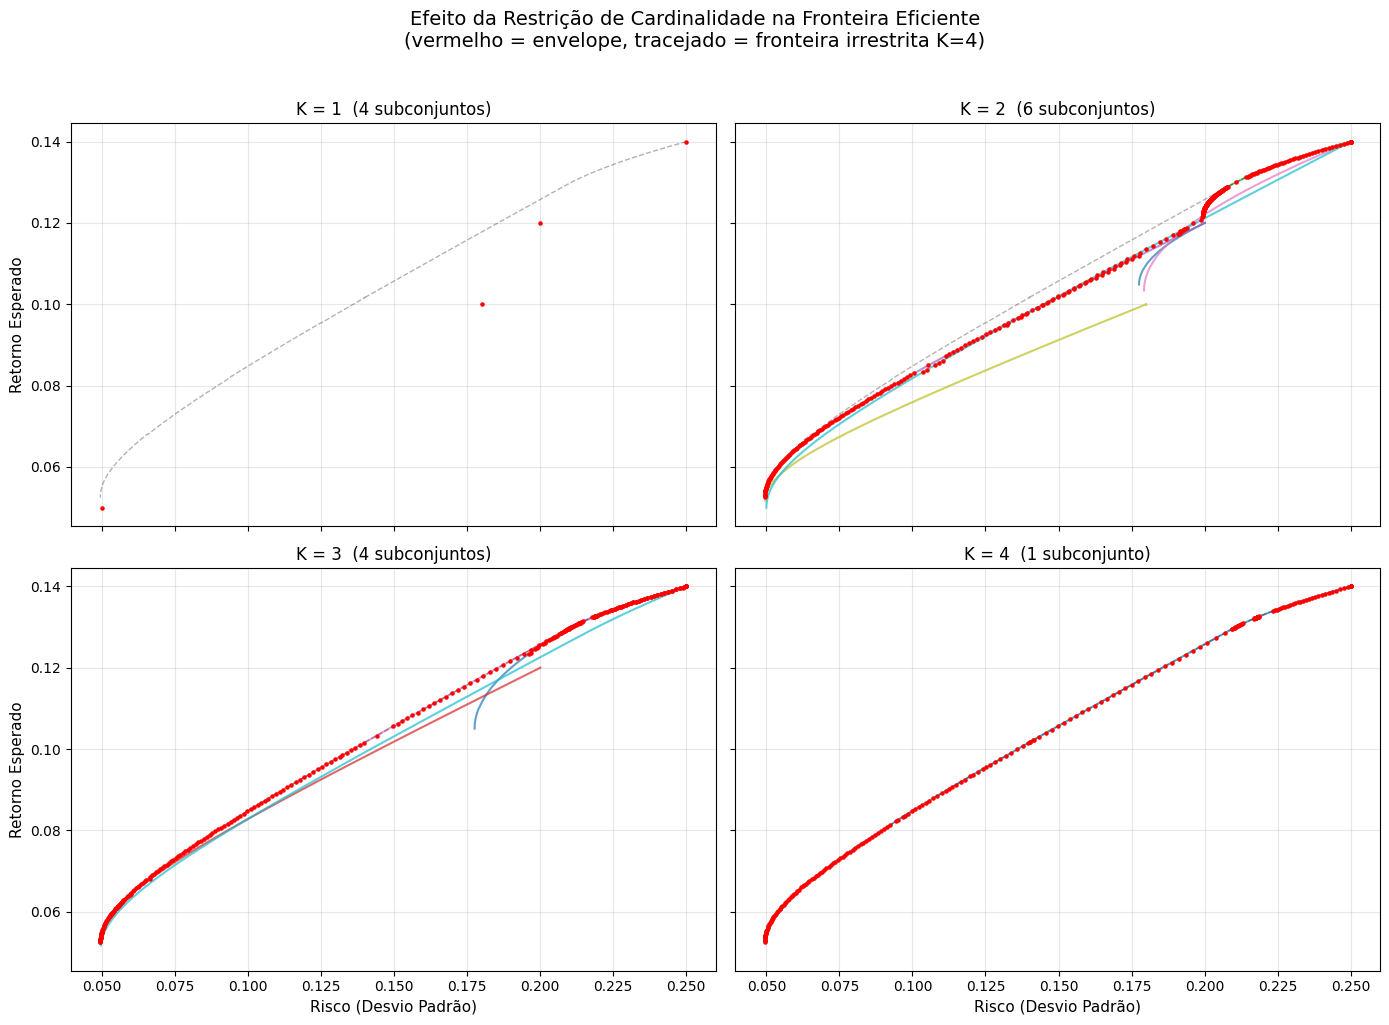

In [ ]:
# --- Gráfico 2: Comparação das fronteiras para K=1, 2, 3, ..., N ---

N = instance_4["n_assets"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for idx, k_val in enumerate(range(1, N + 1)):
    ax = axes[idx]
    frontiers = compute_all_subset_frontiers(instance_4, k=k_val)
    n_subsets = len(frontiers)

    colors = plt.cm.tab10(np.linspace(0, 1, max(n_subsets, 1)))

    for (label, (risks, rets)), color in zip(frontiers.items(), colors):
        ax.plot(risks, rets, '-', linewidth=1.5, color=color, alpha=0.7)

    # Envelope (Pareto front) para este K
    all_risks = np.concatenate([r for r, _ in frontiers.values()])
    all_rets = np.concatenate([r for _, r in frontiers.values()])
    sorted_idx = np.argsort(all_rets)
    p_risks, p_rets = [], []
    min_risk = np.inf
    for i in sorted_idx[::-1]:
        if all_risks[i] < min_risk:
            p_risks.append(all_risks[i])
            p_rets.append(all_rets[i])
            min_risk = all_risks[i]
    ax.scatter(p_risks, p_rets, s=5, color='red', zorder=10)

    # Fronteira irrestrita como referência
    for label, (risks, rets) in frontiers_kn.items():
        ax.plot(risks, rets, 'k--', linewidth=1, alpha=0.3)

    ax.set_title(f"K = {k_val}  ({n_subsets} subconjunto{'s' if n_subsets > 1 else ''})", fontsize=12)
    ax.grid(True, alpha=0.3)

axes[2].set_xlabel("Risco (Desvio Padrão)", fontsize=11)
axes[3].set_xlabel("Risco (Desvio Padrão)", fontsize=11)
axes[0].set_ylabel("Retorno Esperado", fontsize=11)
axes[2].set_ylabel("Retorno Esperado", fontsize=11)

fig.suptitle(f"Efeito da Restrição de Cardinalidade na Fronteira Eficiente (N={N} ativos)\n"
             f"(vermelho = envelope, tracejado = fronteira irrestrita K={N})",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Demonstração com instância real: port1.txt (31 ativos) via Monte Carlo

Para mostrar que o fenômeno persiste em instâncias maiores, usamos **amostragem aleatória** de portfólios com $K=5$ ativos dentre os 31 disponíveis em `port1.txt`. Comparamos a nuvem de pontos factíveis com a fronteira eficiente irrestrita (arquivo `portef1.txt`). As **lacunas** e a **estrutura fragmentada** da nuvem evidenciam a descontinuidade.

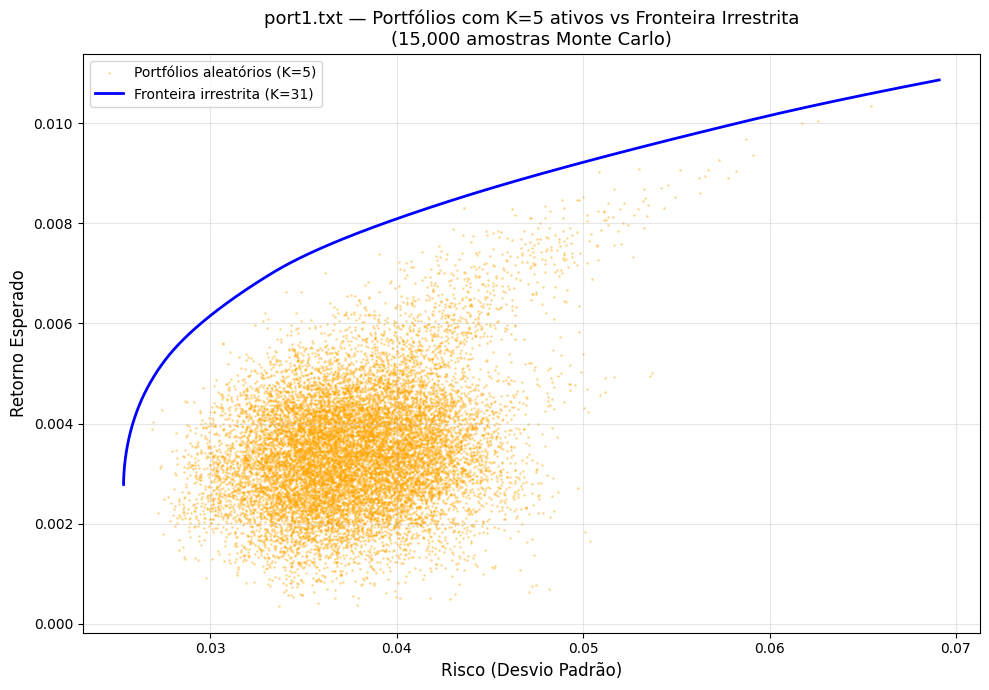


Observe como a região factível com K=5 NÃO cobre toda a fronteira eficiente irrestrita.
As lacunas entre os clusters de pontos ilustram a descontinuidade da fronteira com cardinalidade.


In [7]:
# --- Gráfico 3: Monte Carlo com port1.txt (31 ativos) e K=5 ---

instance_port1 = read_or_library_instance("port1.txt")
n = instance_port1["n_assets"]
returns_p1 = instance_port1["returns"]
cov_p1 = instance_port1["cov_matrix"]

K_mc = 5
n_samples = 15000
mc_risks, mc_rets = [], []

rng = np.random.default_rng(42)

for _ in range(n_samples):
    # Seleciona K ativos aleatoriamente
    selected = rng.choice(n, size=K_mc, replace=False)
    
    # Gera pesos aleatórios via Dirichlet (uniformemente no simplex)
    w_sub = rng.dirichlet(np.ones(K_mc))
    
    # Calcula retorno e risco
    w_full = np.zeros(n)
    w_full[selected] = w_sub
    
    ret = returns_p1 @ w_full
    risk = np.sqrt(w_full @ cov_p1 @ w_full)
    mc_risks.append(risk)
    mc_rets.append(ret)

mc_risks = np.array(mc_risks)
mc_rets = np.array(mc_rets)

# Carrega fronteira eficiente irrestrita
df_portef = pd.read_csv('portef1.txt', sep=r"\s+", header=None, names=["mean_return", "variance"])
df_portef["std_dev"] = np.sqrt(df_portef["variance"])

fig, ax = plt.subplots(figsize=(10, 7))

# Nuvem Monte Carlo
ax.scatter(mc_risks, mc_rets, s=1, alpha=0.3, color='orange', label=f'Portfólios aleatórios (K={K_mc})')

# Fronteira eficiente irrestrita
ax.plot(df_portef["std_dev"], df_portef["mean_return"], 'b-', linewidth=2, label='Fronteira irrestrita (K=31)')

ax.set_xlabel("Risco (Desvio Padrão)", fontsize=12)
ax.set_ylabel("Retorno Esperado", fontsize=12)
ax.set_title(f"port1.txt — Portfólios com K={K_mc} ativos vs Fronteira Irrestrita\n"
             f"({n_samples:,} amostras Monte Carlo)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nObserve como a região factível com K={K_mc} NÃO cobre toda a fronteira eficiente irrestrita.")
print("As lacunas entre os clusters de pontos ilustram a descontinuidade da fronteira com cardinalidade.")